# Example notebook for Ensemble of Zonal (lev-lon) diagnostic of temperature

##### This notebook demonsterates how the ensemble module can be used for Zonal data (lev-lon) temperature data from a single ensemble or multi-model ensemble memebers

In [1]:
from aqua.diagnostics import EnsembleZonal, PlotEnsembleZonal, merge_from_data_files
import matplotlib.pyplot as plt

%matplotlib inline

/work/ab0995/a270260/conda_envs/aqua-dev/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/work/ab0995/a270260/conda_envs/aqua-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### loading the data as xarray Datasets
##### Here we are using two same files because we have only this file yet with same lev-lat
##### loading the Zonal Datasets

In [2]:
file_0 = "/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-NEMO/historical-1990/ocean3d_drift/netcdf/IFS-NEMO-historical-1990-lra-r100-monthly_zonal_mean_trend_atlantic_ocean.nc"
file_1 = "/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-NEMO/historical-1990/ocean3d_drift/netcdf/IFS-NEMO-historical-1990-lra-r100-monthly_zonal_mean_trend_atlantic_ocean.nc"
file_list = [file_0, file_1]

##### path on lumi

In [3]:
# IFS-NEMO: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-NEMO/historical-1990/ocean3d_drift/netcdf/IFS-NEMO-historical-1990-lra-r100-monthly_zonal_mean_trend_atlantic_ocean.nc

##### merging the dataset along the dimension ens_dim
##### ens_dim="ensemble" name can be changed.
##### It should remain consistent with the ensemble name for the EnsembleZonal class variable

In [4]:
ens_dataset = merge_from_data_files(variable="avg_so", data_path_list=file_list, loglevel="WARNING", ens_dim="ensemble")

sh: getfattr: command not found
sh: getfattr: command not found


In [5]:
# from collections import Counter
# len(ens_dataset.model)
model_counts = ens_dataset.model.values
model_counts

array(['model_name', 'model_name'], dtype='<U10')

In [6]:
zonal_ens = EnsembleZonal(var="avg_so", dataset=ens_dataset)

In [7]:
zonal_ens.run()

sh: getfattr: command not found
sh: getfattr: command not found


In [8]:
var = "avg_so"
plot_class_arguments = {"model_list": ["IFS-NEMO", "IFS-NEMO"]}

plot_arguments = {
    "var": var,
    "save_format": ["png", "pdf", "svg"],
    "cbar_label": "Time-mean sea water practical salinity g kg**-1/year",
}

In [9]:
ens_zm_plot = PlotEnsembleZonal(**plot_class_arguments)
dataset_mean = zonal_ens.dataset_mean
dataset_std = zonal_ens.dataset_std
title_mean = "Mean of Ensemble of Zonal-average of avg_so"
title_std = "Standard deviation of Ensemble of Zonal-average of avg_so"

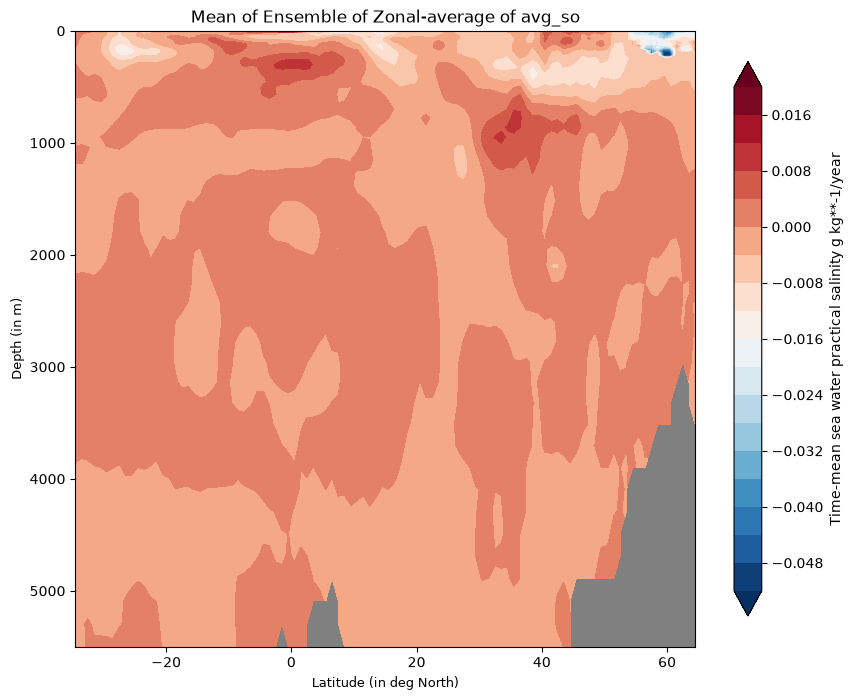

In [10]:
plot_dict = ens_zm_plot.plot(**plot_arguments, dataset=dataset_mean, title=title_mean)

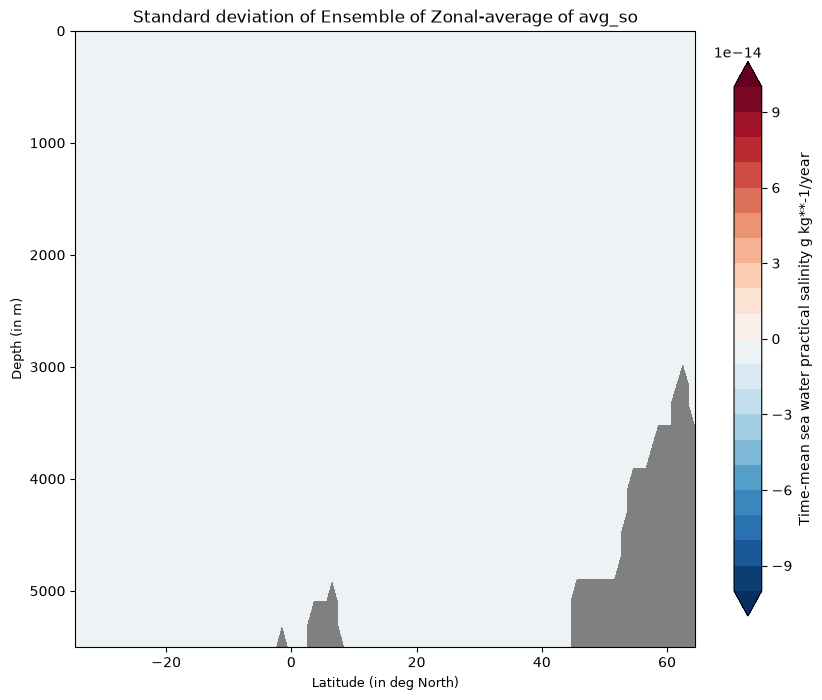

In [11]:
plot_dict = ens_zm_plot.plot(**plot_arguments, dataset=dataset_std, title=title_std)